In [1]:
using LinearAlgebra
using LinearOperators
using SparseArrays
include("main.jl")

get_grid_points_as_1d_vect (generic function with 1 method)

In [2]:
n = 64
d = 2
N = n^d

4096

In [3]:
beta = 4.0 * pi
gamma = 2.0
alpha = gamma / beta^2

function u_analytic_fun(t, x)
    prod(sin.(beta*x)) * exp(- gamma * t)
end

alpha

0.012665147955292222

In [4]:
h = 1 / (n+1)

t_max = 0.1
n_iters = 10
tau = t_max / (n_iters-1)
h, tau

(0.015384615384615385, 0.011111111111111112)

In [5]:
# need r <= 1 (implicit) or 1/2 (explicit)
r = alpha * tau / h^2

0.5945583345678849

In [6]:
grid_points_as_1d_vect = get_grid_points_as_1d_vect(n,d);

In [7]:
U_0 = u_analytic_fun.(0, grid_points_as_1d_vect);

In [8]:
L = get_laplace_sparse_matrix(n,d);

In [9]:
r = alpha * tau / h^2

0.5945583345678849

### Explicit

In [10]:
A_expl = sparse(I, N, N) + r * L;

In [11]:
U_evol_expl = zeros(n_iters, N)
U_evol_expl[1, :] = U_0
for t in 2:1:n_iters
    U_evol_expl[t, :] = A_expl * U_evol_expl[t-1, :];
end

In [12]:
U_evol_expl

10×4096 Matrix{Float64}:
 0.0369127  0.07245    0.105288   …  0.105288   0.07245    0.0369127
 0.0352772  0.06924    0.100623      0.100623   0.06924    0.0352772
 0.0337142  0.0661723  0.0961647     0.0961647  0.0661723  0.0337142
 0.0322205  0.0632404  0.091904      0.091904   0.0632404  0.0322205
 0.0307929  0.0604385  0.0878321     0.0878321  0.0604385  0.0307929
 0.0294286  0.0577607  0.0839406  …  0.0839406  0.0577607  0.0294286
 0.0281247  0.0552015  0.0802215     0.0802215  0.0552015  0.0281247
 0.0268786  0.0527557  0.0766672     0.0766672  0.0527557  0.0268786
 0.0256877  0.0504183  0.0732704     0.0732704  0.0504183  0.0256877
 0.0245496  0.0481845  0.070024      0.070024   0.0481845  0.0245496

### Implicit

In [13]:
using IterativeSolvers

In [14]:
A_impl = sparse(I, N, N) - r * L;

In [15]:
U_evol_impl = zeros(n_iters, N)
U_evol_impl[1, :] = U_0
for t in 2:1:n_iters
    U_evol_impl[t, :] = cg(A_impl, U_evol_impl[t-1, :]; verbose=true);
end

  1	3.53e-14

  1	3.42e-14

  1	3.33e-14

  1	3.13e-14

  1	3.00e-14

  1	2.92e-14

  1	2.84e-14

  1	2.71e-14

  1	2.61e-14



In [16]:
U_evol_impl

10×4096 Matrix{Float64}:
 0.0369127  0.07245    0.105288   …  0.105288   0.07245    0.0369127
 0.0353466  0.0693762  0.100821      0.100821   0.0693762  0.0353466
 0.033847   0.0664328  0.0965434     0.0965434  0.0664328  0.033847
 0.032411   0.0636143  0.0924474     0.0924474  0.0636143  0.032411
 0.0310359  0.0609154  0.0885252     0.0885252  0.0609154  0.0310359
 0.0297191  0.058331   0.0847694  …  0.0847694  0.058331   0.0297191
 0.0284583  0.0558562  0.0811729     0.0811729  0.0558562  0.0284583
 0.0272509  0.0534864  0.077729      0.077729   0.0534864  0.0272509
 0.0260947  0.0512172  0.0744313     0.0744313  0.0512172  0.0260947
 0.0249876  0.0490442  0.0712734     0.0712734  0.0490442  0.0249876

### Operator approach

In [17]:
function a_op!(v_new, v)
    v_new .= v - r * laplace_operator(v)
end

a_op! (generic function with 1 method)

In [18]:
A_op = LinearOperator(Float64, N, N, true, true, a_op!)

Linear operator
  nrow: 4096
  ncol: 4096
  eltype: Float64
  symmetric: true
  hermitian: true
  nprod:   0
  ntprod:  0
  nctprod: 0



In [19]:
U_evol_op = zeros(n_iters, N)
U_evol_op[1, :] = U_0
for t in 2:1:n_iters
    U_evol_op[t, :] = cg(A_op, U_evol_op[t-1, :]; verbose=true);
end

  1	3.73e-14

  1	3.38e-14

  1	3.38e-14

  1	3.07e-14

  1	2.97e-14

  1	2.89e-14

  1	2.81e-14

  1	2.66e-14

  1	2.55e-14



---

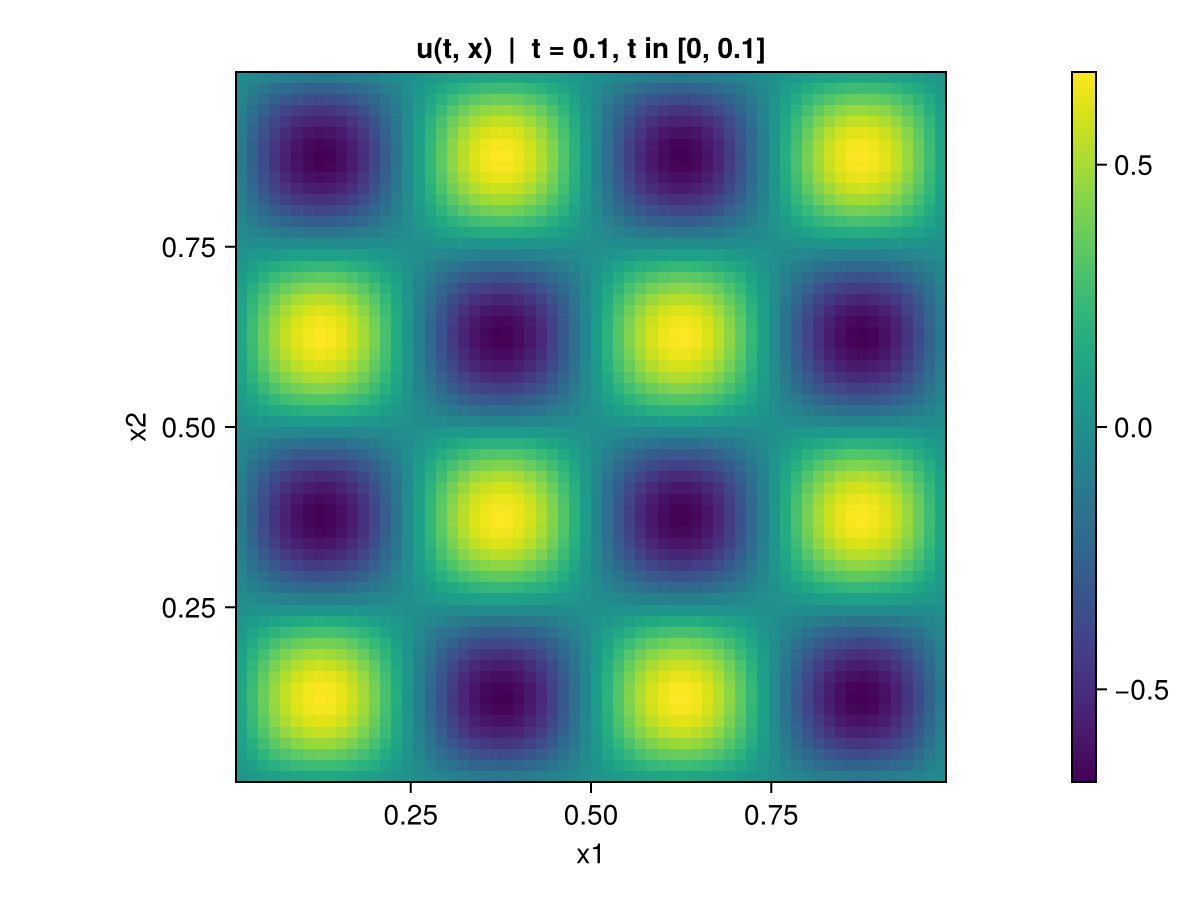

In [23]:
using CairoMakie

ti = n_iters

t = (ti-1) * tau
U = U_evol_op[ti, :]
#U = u_analytic_fun.(t, grid_points_as_1d_vect);

h = 1/(n+1)
xs = range(h, 1-h; length=n)
U_matrix = reshape(U, ntuple(_ -> n, d)...)

fig, ax, hm = heatmap(xs, xs, U_matrix,
    colormap = :viridis,
    axis = (title = "u(t, x)  |  t = $t, t in [0, $t_max]", xlabel = "x1", ylabel = "x2", aspect = 1)
)
Colorbar(fig[1, 2], hm)
fig